In [16]:
import sys
import os
sys.path.append(os.path.abspath('../../'))

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from modules.data.dataset_utils import create_senteces_from_data
from scipy.stats import spearmanr
import seaborn as sns
import pandas as pd
import numpy as np
import json
import re
sns.set_style('darkgrid')

In [17]:
eye_tracking_feature = 'dur'
positive_corr = True
eye_tracking_dir = '../../data/geco/dataset/'
model_attention_dir = '../../attentions/' 

In [18]:
def load_eye_tracking_data(src_path, col):
    data = pd.read_csv(src_path, index_col=0)
    gaze_dataset = create_senteces_from_data(data, [col], keep_id=True)
    return gaze_dataset

In [19]:
def load_model_attention(src_path):
    with open(src_path, 'r') as src_file:
        model_attention = json.load(src_file)   
    return model_attention

In [20]:
def normalize_list(l):
    return ((l-np.min(l))/(np.max(l)-np.min(l))).tolist()

In [21]:
def compute_correlation(eye_tracking_dataset, model_attention_dict):
    all_human_attentions = []
    all_model_attentions = []
    feature_name = [col_name for col_name in eye_tracking_dataset.column_names if col_name not in ['id', 'text']][0]

    for sent_id, human_attention in zip(eye_tracking_dataset['id'], eye_tracking_dataset[feature_name]):
        try:
            model_attention = model_attention_dict[sent_id]
            all_human_attentions += normalize_list(human_attention)
            all_model_attentions += normalize_list(model_attention)
        except:
            pass

    s = spearmanr(all_model_attentions, all_human_attentions)
    if s.pvalue < 0.05:
        if positive_corr:
            return max(s.statistic, -s.statistic)
        else:
            return s.statistic
    else:
        return 0.0

In [23]:
def compute_correlation_df_across_epochs(model_attention_dir, eye_tracking_data):
    correlations_dict = {'epoch':[], 'layer':[], 'correlation':[]}
    for checkpoint_dir in os.listdir(model_attention_dir):
        checkpoint_path = os.path.join(model_attention_dir, checkpoint_dir)
        epoch = int(checkpoint_dir.split('-')[-1])*10
        for layer in range(12):
            layer_attention_path = os.path.join(checkpoint_path, f'{layer}.json')
            layer_attention = load_model_attention(layer_attention_path)
            corr = compute_correlation(eye_tracking_data, layer_attention)
            correlations_dict['epoch'].append(epoch)
            correlations_dict['layer'].append(layer)
            correlations_dict['correlation'].append(corr)
    return pd.DataFrame.from_dict(correlations_dict)

In [26]:
all_correlation_dfs = []
for model_name in os.listdir(model_attention_dir):
    user_id = re.findall(r'pp(\d*)_', model_name)[0]
    learning_rate = re.findall(r'lr(.*)$', model_name)[0]
    user_attention_dir = os.path.join(model_attention_dir, model_name)
    eye_tracking_path = os.path.join(eye_tracking_dir, f'pp{user_id}_dataset_test.csv')
    eye_tracking_data = load_eye_tracking_data(eye_tracking_path, eye_tracking_feature)
    correlations_df = compute_correlation_df_across_epochs(user_attention_dir, eye_tracking_data)
    correlations_df['user'] = user_id
    correlations_df['learning_rate'] = learning_rate
    all_correlation_dfs.append(correlations_df)
all_correlation_dfs = pd.concat(all_correlation_dfs, axis=0)

In [43]:
all_correlation_dfs['learning_rate'].unique()

array(['5e-05_wd', '1e-05_wd', '5e-05', '1e-05'], dtype=object)

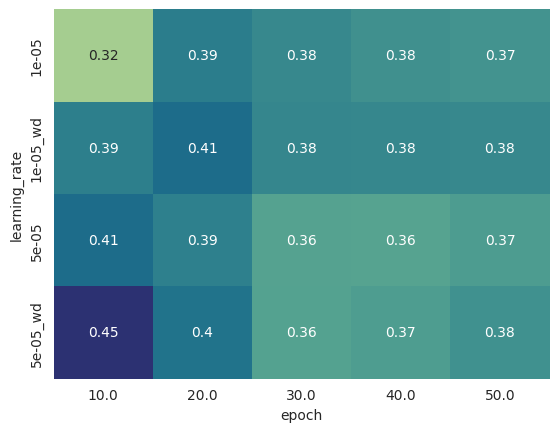

In [46]:
h = all_correlation_dfs[all_correlation_dfs['epoch']<51][['epoch', 'learning_rate', 'correlation']].groupby(['epoch','learning_rate']).max().reset_index().pivot(index='learning_rate', columns='epoch', values='correlation')
sns.heatmap(data=h, annot=True, cmap='crest', cbar=False);

In [8]:
all_correlation_dfs = []
for file_name in os.listdir(eye_tracking_dir):
    if 'test' in file_name:
        user_id =  re.findall(r'pp(\d*)_', file_name)[0]
        user_attention_dir = os.path.join(model_attention_dir, f'roberta-base_pp{user_id}_50epochs_lr5e-05_wd')
        eye_tracking_path = os.path.join(eye_tracking_dir, file_name)
        eye_tracking_data = load_eye_tracking_data(eye_tracking_path, eye_tracking_feature)
        correlations_df = compute_correlation_df_across_epochs(user_attention_dir, eye_tracking_data)
        correlations_df['user'] = user_id
        all_correlation_dfs.append(correlations_df)

In [9]:
all_correlation_dfs = pd.concat(all_correlation_dfs, axis=0)

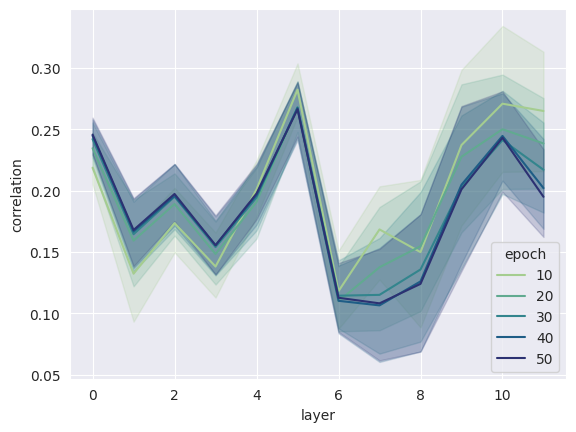

In [10]:
sns.lineplot(data=all_correlation_dfs, x='layer', y='correlation', hue='epoch', palette='crest');

In [ ]:
# eye_tracking_data = load_eye_tracking_data(eye_tracking_path, eye_tracking_feature)

In [ ]:
# model_attention_dir = '../../attentions/roberta-base_pp21_50epochs_lr1e-05' 

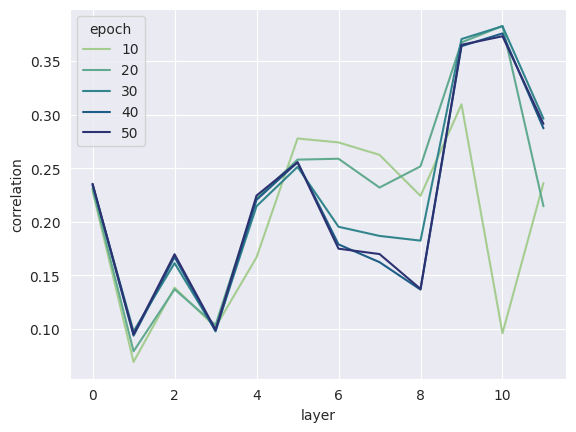

In [ ]:
# correlations_df = compute_correlation_df_across_epochs(model_attention_dir, eye_tracking_data)
# sns.lineplot(data=correlations_df, x='layer', y='correlation', hue='epoch', palette='crest');

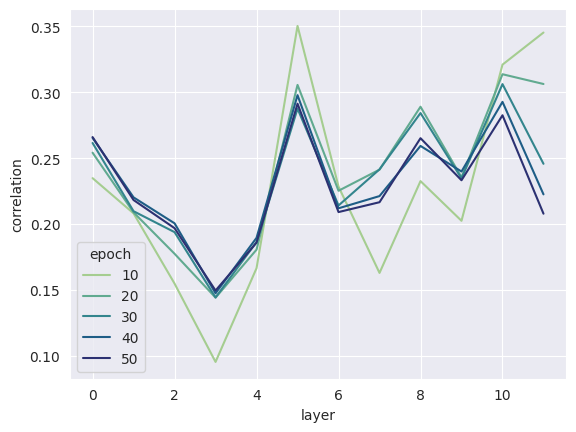

In [ ]:
# model_attention_dir = '../../attentions/roberta-base_pp21_50epochs_lr5e-05'
# correlations_df = compute_correlation_df_across_epochs(model_attention_dir, eye_tracking_data)
# sns.lineplot(data=correlations_df, x='layer', y='correlation', hue='epoch', palette='crest');

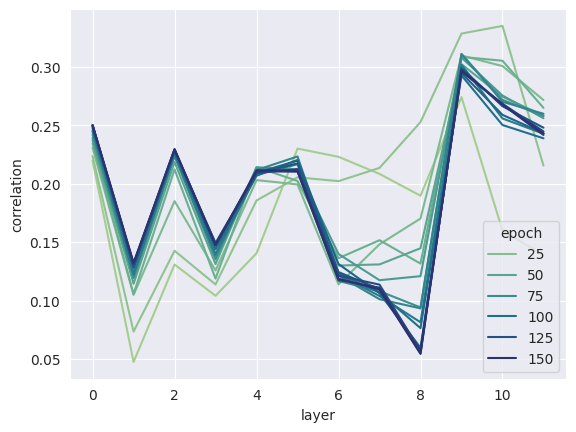

In [11]:
model_attention_dir = '../../attentions/roberta-base_pp21_150epochs_lr1e-05'
correlations_df = compute_correlation_df_across_epochs(model_attention_dir, eye_tracking_data)
sns.lineplot(data=correlations_df, x='layer', y='correlation', hue='epoch', palette='crest');

In [ ]:
# eye_tracking_data = load_eye_tracking_data(eye_tracking_path, eye_tracking_feature)
# for layer in range(12):
#     layer_attention_path = os.path.join(model_attention_dir, f'{layer}.json')
#     layer_attention = load_model_attention(layer_attention_path)
    
#     corr = compute_correlation(eye_tracking_data, layer_attention)
#     print(layer, corr)